# 06 - Random Forest

## Conceito
Random Forest e um ensemble de arvores de decisao. Cada arvore e treinada em
uma amostra bootstrap dos dados e em um subconjunto aleatorio de features em
cada split. A previsao final e a media (regressao) ou voto majoritario
(classificacao).

## Por que funciona
A aleatoriedade descorrelaciona as arvores. Erros individuais se cancelam na
media, reduzindo variancia sem aumentar muito o vies.

## Hiperparametros principais
- n_estimators: numero de arvores (mais e melhor, com retorno decrescente)
- max_depth: profundidade maxima de cada arvore
- max_features: features consideradas por split (sqrt e o padrao em classificacao)
- min_samples_leaf, min_samples_split: controle de overfitting
- bootstrap: amostragem com reposicao
- oob_score: usa amostras fora do bootstrap como validacao

## Vantagens
- Robusto, bom desempenho com pouco ajuste
- Lida com dados faltantes e outliers razoavelmente bem
- Fornece importancia de features
- Paraleliza bem (n_jobs)

## Desvantagens
- Menos interpretavel que uma arvore unica
- Mais custoso em treino e previsao
- Nao extrapola em regressao

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

dados = load_breast_cancer()
X, y = dados.data, dados.target # type: ignore

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Comparacao: arvore unica vs random forest
arvore = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
floresta = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)

for nome, modelo in [("Arvore", arvore), ("Random Forest", floresta)]:
    ac_tr = accuracy_score(y_train, modelo.predict(X_train))
    ac_te = accuracy_score(y_test, modelo.predict(X_test))
    print(f"{nome:<15} treino={ac_tr:.3f} teste={ac_te:.3f}")

Arvore          treino=1.000 teste=0.912
Random Forest   treino=1.000 teste=0.956


## Efeito do numero de arvores

Mais arvores reduzem variancia, mas com retorno decrescente. Ha um ponto
em que adicionar arvores nao melhora mais.

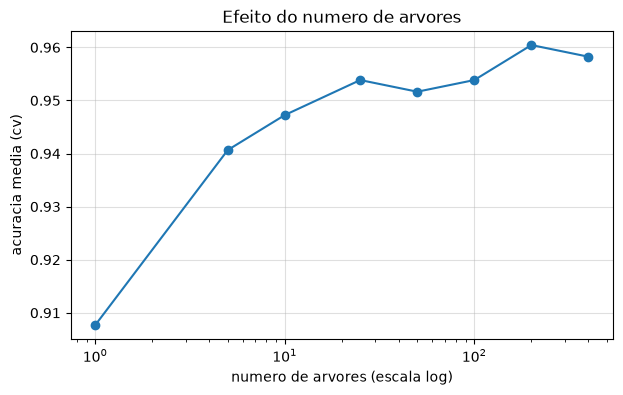

In [6]:
n_arvores = [1, 5, 10, 25, 50, 100, 200, 400]
acuracias = []

for n in n_arvores:
    modelo = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    scores = cross_val_score(modelo, X_train, y_train, cv=5)
    acuracias.append(scores.mean())

plt.figure(figsize=(7, 4))
plt.plot(n_arvores, acuracias, marker="o")
plt.xscale("log")
plt.xlabel("numero de arvores (escala log)")
plt.ylabel("acuracia media (cv)")
plt.title("Efeito do numero de arvores")
plt.grid(True, alpha=0.4)
plt.show()

## Importancia das features

Random Forest calcula importancia por reducao media de impureza. Ha tambem
importancia por permutacao (permutation_importance), mais robusta.

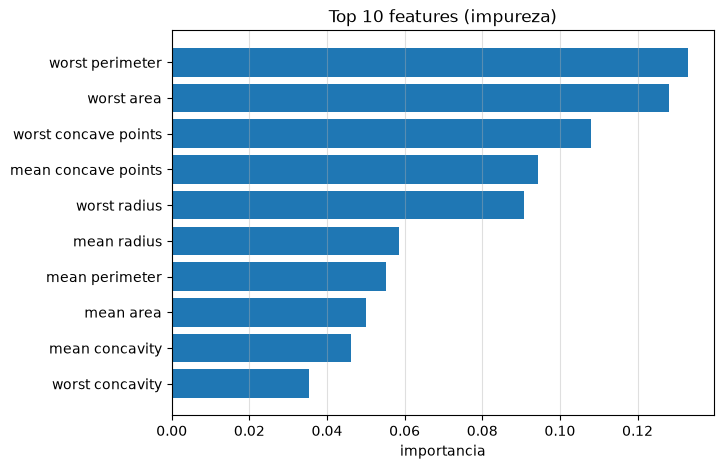

In [7]:
importancias = floresta.feature_importances_
ordem = np.argsort(importancias)[::-1][:10]

plt.figure(figsize=(7, 5))
plt.barh(
    [dados.feature_names[i] for i in ordem][::-1], #type: ignore
    [importancias[i] for i in ordem][::-1],
    color="tab:blue",
)
plt.xlabel("importancia")
plt.title("Top 10 features (impureza)")
plt.grid(axis="x", alpha=0.4)
plt.show()

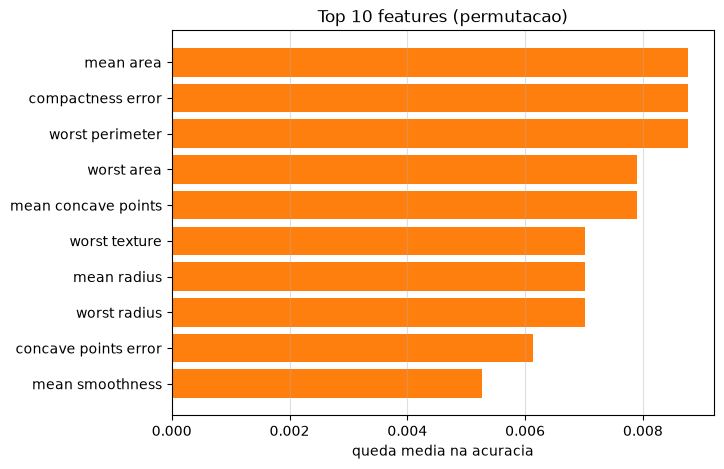

In [8]:
from sklearn.inspection import permutation_importance

resultado = permutation_importance(
    floresta, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

ordem = np.argsort(resultado.importances_mean)[::-1][:10] #type: ignore

plt.figure(figsize=(7, 5))
plt.barh(
    [dados.feature_names[i] for i in ordem][::-1], #type: ignore
    [resultado.importances_mean[i] for i in ordem][::-1], #type: ignore
    color="tab:orange",
)
plt.xlabel("queda media na acuracia")
plt.title("Top 10 features (permutacao)")
plt.grid(axis="x", alpha=0.4)
plt.show()

## Out-of-bag score

Quando bootstrap=True, cerca de 1/3 das amostras fica de fora de cada arvore.
Essas amostras formam uma validacao interna gratuita.

In [9]:
modelo_oob = RandomForestClassifier(
    n_estimators=200, oob_score=True, bootstrap=True, random_state=42, n_jobs=-1
)
modelo_oob.fit(X_train, y_train)
print("OOB score:", round(modelo_oob.oob_score_, 3))
print("Acuracia teste:", round(accuracy_score(y_test, modelo_oob.predict(X_test)), 3))

OOB score: 0.96
Acuracia teste: 0.956


In [10]:
print(classification_report(y_test, floresta.predict(X_test), target_names=dados.target_names)) #type: ignore

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Exercicios

1. Compare RandomForestClassifier com GradientBoostingClassifier no mesmo dataset.
2. Ajuste max_depth e veja o efeito no desempenho.
3. Repita o fluxo para regressao usando RandomForestRegressor no dataset diabetes.
4. Explique por que a media de arvores descorrelacionadas reduz a variancia.